## Ejercicio 3: Inspección visual de un producto

### Ficha PEAS

| Elemento | Descripción |
|---|---|
| **P — Medida de desempeño** | Detectar productos defectuosos correctamente, reducir productos defectuosos enviados al cliente y evitar rechazos innecesarios. |
| **E — Entorno** | Línea de producción, productos, cámara de inspección y área de control de calidad. |
| **A — Actuadores** | Aprobar producto, enviar a revisión manual o rechazar producto. |
| **S — Percepciones** | Matriz de imagen de 5×5 píxeles, donde 0 representa un píxel normal y 1 representa un píxel defectuoso. |
| **Objetivo** | Clasificar cada producto según la cantidad de defectos detectados en su imagen. |
| **Tipo de agente** | Agente reactivo simple, porque decide según la imagen actual recibida por la cámara. |

### Justificación de las reglas

Un producto sin píxeles defectuosos puede aprobarse porque no presenta anomalías en la inspección. Los productos con uno a tres defectos pasan a revisión manual, ya que un operador puede confirmar si los defectos afectan la calidad real. Si existen más de tres píxeles defectuosos, se rechaza el producto porque existe mayor probabilidad de una falla significativa. Estas reglas ayudan a equilibrar la calidad del producto y el costo de inspección.

### Código

In [2]:
import numpy as np

def agente_inspeccion(imagen):
    """
    Percepción (S): matriz de NumPy de 5x5.
    0 representa un píxel normal y 1 representa un píxel defectuoso.
    """

    if imagen.shape != (5, 5):
        return "imagen invalida", "la imagen debe tener dimensiones de 5x5 pixeles"

    if not np.all(np.isin(imagen, [0, 1])):
        return "imagen invalida", "la matriz solo debe contener valores 0 y 1"

    defectos = np.sum(imagen == 1)

    if defectos == 0:
        return "aprobar", "no se detectaron pixeles defectuosos"

    elif defectos <= 3:
        return "enviar a revision manual", f"se detectaron {defectos} pixeles defectuosos"

    else:
        return "rechazar", f"se detectaron {defectos} pixeles defectuosos"

### Simulación y pruebas

In [3]:
imagenes_prueba = {
    "Producto sin defectos": np.array([
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
    ]),

    "Producto con 1 defecto": np.array([
        [0, 0, 0, 0, 0],
        [0, 1, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
    ]),

    "Producto con 3 defectos - caso limite": np.array([
        [0, 0, 0, 0, 0],
        [0, 1, 0, 0, 0],
        [0, 0, 0, 1, 0],
        [0, 0, 0, 0, 0],
        [0, 1, 0, 0, 0],
    ]),

    "Producto con 5 defectos": np.array([
        [1, 0, 0, 0, 1],
        [0, 1, 0, 0, 0],
        [0, 0, 0, 1, 0],
        [0, 0, 0, 0, 0],
        [0, 1, 0, 0, 0],
    ]),
}

for nombre, imagen in imagenes_prueba.items():
    accion, motivo = agente_inspeccion(imagen)

    print(nombre)
    print(imagen)
    print(f"Decisión: {accion}")
    print(f"Motivo: {motivo}")
    print("-" * 70)

Producto sin defectos
[[0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]]
Decisión: aprobar
Motivo: no se detectaron pixeles defectuosos
----------------------------------------------------------------------
Producto con 1 defecto
[[0 0 0 0 0]
 [0 1 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]]
Decisión: enviar a revision manual
Motivo: se detectaron 1 pixeles defectuosos
----------------------------------------------------------------------
Producto con 3 defectos - caso limite
[[0 0 0 0 0]
 [0 1 0 0 0]
 [0 0 0 1 0]
 [0 0 0 0 0]
 [0 1 0 0 0]]
Decisión: enviar a revision manual
Motivo: se detectaron 3 pixeles defectuosos
----------------------------------------------------------------------
Producto con 5 defectos
[[1 0 0 0 1]
 [0 1 0 0 0]
 [0 0 0 1 0]
 [0 0 0 0 0]
 [0 1 0 0 0]]
Decisión: rechazar
Motivo: se detectaron 5 pixeles defectuosos
----------------------------------------------------------------------


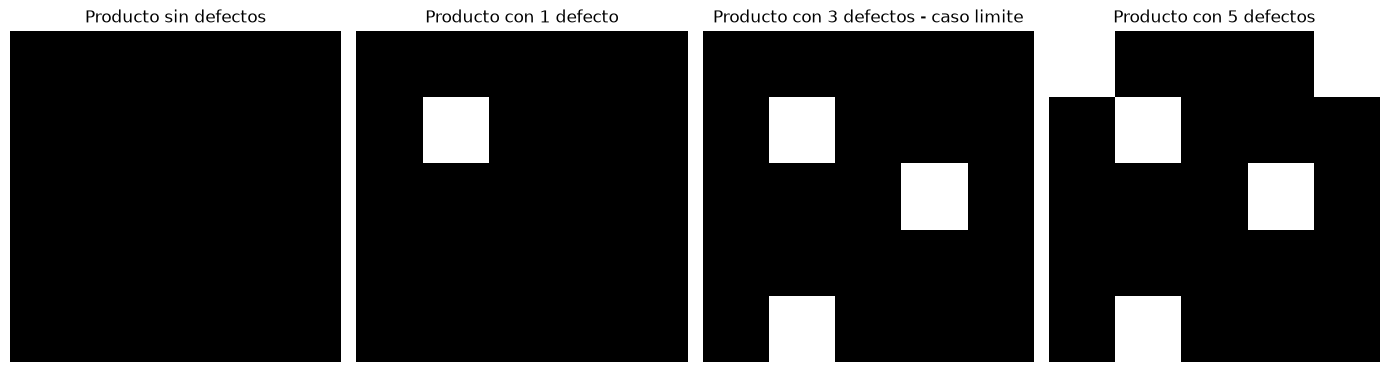

In [4]:
import matplotlib.pyplot as plt

fig, ejes = plt.subplots(1, 4, figsize=(14, 4))

for eje, (nombre, imagen) in zip(ejes, imagenes_prueba.items()):
    eje.imshow(imagen, cmap="gray", vmin=0, vmax=1)
    eje.set_title(nombre)
    eje.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
S